# XGBoost 개선 버전
### 변경사항
1. Rolling 피처 추가 (누수 방지 shift 적용)
2. CDD 재확인 및 고온 구간 피처 보강
3. Optuna + TimeSeriesSplit CV 기반 튜닝
4. 과적합 진단 시각화
5. 고온 구간 별도 성능 평가

## 📦 라이브러리 임포트
**핵심 라이브러리 설명**
- `pandas / numpy` : 데이터 처리 및 수치 연산
- `optuna` : 하이퍼파라미터 자동 최적화 (베이지안 탐색)
- `TimeSeriesSplit` : 시계열 데이터 전용 교차검증 - 미래 데이터 누수 방지
- `XGBRegressor` : 최종 선택 모델 (그래디언트 부스팅 트리)
- `r2_score / RMSE / MAPE` : 회귀 성능 평가 지표 3종

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

# 폰트 설정 (경로는 본인 환경에 맞게)
font_path = r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\5_fonts\Pretendard-Medium.otf"
font_name = fm.FontProperties(fname=font_path).get_name()
fm.fontManager.addfont(font_path)
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False
print(f'폰트: {font_name}')

폰트: Pretendard


## 1. 데이터 로드 및 피처 엔지니어링

## 📂 데이터 로드
**주의사항**
- `sort_values('datetime')` : 시계열 데이터는 반드시 날짜 순 정렬 후 사용
- 강수량·일사량 결측치를 0으로 채우는 이유 : 비가 안 오면 0, 일사 없으면 0이 물리적으로 맞음

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\1_data\processed\df_final_v2.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)  # 시계열 정렬 필수

# 결측치 처리
df['강수량(mm)'] = df['강수량(mm)'].fillna(0)
df['일사(MJ/m2)'] = df['일사(MJ/m2)'].fillna(0)

print(f'데이터 기간: {df["datetime"].min()} ~ {df["datetime"].max()}')
print(f'전체 행 수: {len(df):,}')
df.head(3)

데이터 기간: 2023-01-08 01:00:00 ~ 2025-01-01 00:00:00
전체 행 수: 17,376


,기준일자,기준시,전력사용량(MWh),datetime,기온(°C),강수량(mm),풍속(m/s),습도(%),일사(MJ/m2),전운량(10분위),...,is_weekend,is_holiday,is_off,CDD,HDD,lag_24,lag_168,rolling_24h,체감온도,불쾌지수
0,2023-01-08,1,3758,2023-01-08 01:00:00,-1.8,0.0,0.7,74.0,0.0,0.0,...,1,0,1,0.0,19.8,3906.0,3783.0,4545.541667,-1.800000,32.94132
1,2023-01-08,2,3514,2023-01-08 02:00:00,-2.0,0.0,1.7,74.0,0.0,8.0,...,1,0,1,0.0,20.0,3600.0,3567.0,4539.375000,-4.375528,32.63280
2,2023-01-08,3,3361,2023-01-08 03:00:00,-2.4,0.0,0.7,77.0,0.0,0.0,...,1,0,1,0.0,20.4,3424.0,3364.0,4535.791667,-2.400000,31.51548


## 🔧 피처 엔지니어링 - Rolling & 고온 피처
**핵심 개념: shift(1) 누수 방지**
```
❌ 잘못된 방법: df[TARGET].rolling(3).mean()
   → 현재 시점 값이 포함되어 미래 정보 누수 발생 (Data Leakage)

✅ 올바른 방법: df[TARGET].shift(1).rolling(3).mean()
   → 1시간 전부터의 과거 데이터만 사용 (안전)
```

**추가된 피처 설명**
| 피처 | 의미 | 도입 이유 |
|------|------|---------|
| rolling_3h_mean | 최근 3시간 평균 소비량 | 단기 트렌드 파악 |
| rolling_6h_max | 최근 6시간 최대 소비량 | 피크 수준 파악 |
| rolling_24h_std | 최근 24시간 표준편차 | 변동성 파악 |
| CDD_squared | CDD의 제곱 | 고온에서 냉방 수요가 비선형적으로 급증하는 패턴 반영 |
| is_heatwave | 33°C 이상 여부 (0/1) | 폭염 구간 명시적 표시 |
| temp_humidity | 기온 × 습도 | 체감 더위 = 실제 냉방 수요와 더 밀접 |

In [3]:
# ── Rolling 피처 (shift(1)로 미래 누수 방지) ──────────────────────────
TARGET = '전력사용량(MWh)'

# 과거 소비량 기반 rolling (shift(1) = 현재 시점 제외)
df['rolling_3h_mean']  = df[TARGET].shift(1).rolling(3).mean()   # 최근 3시간 평균
df['rolling_6h_mean']  = df[TARGET].shift(1).rolling(6).mean()   # 최근 6시간 평균
df['rolling_6h_max']   = df[TARGET].shift(1).rolling(6).max()    # 최근 6시간 최대
df['rolling_24h_mean'] = df[TARGET].shift(1).rolling(24).mean()  # 최근 24시간 평균
df['rolling_24h_std']  = df[TARGET].shift(1).rolling(24).std()   # 최근 24시간 표준편차 (변동성)

# 기온 기반 rolling (기상 예보 대용)
df['temp_3h_mean']  = df['기온(°C)'].shift(1).rolling(3).mean()
df['temp_6h_max']   = df['기온(°C)'].shift(1).rolling(6).max()

# ── 고온 구간 강조 피처 ──────────────────────────────────────────────
# CDD/HDD 이미 있으면 덮어쓰지 않음 - 없을 경우를 대비해 재계산
if 'CDD' not in df.columns:
    df['CDD'] = np.maximum(0, df['기온(°C)'] - 24)
if 'HDD' not in df.columns:
    df['HDD'] = np.maximum(0, 18 - df['기온(°C)'])

# 고온 구간 플래그 (33도 이상 = 폭염 수준)
df['is_heatwave'] = (df['기온(°C)'] >= 33).astype(int)

# CDD 제곱 (고온일수록 냉방 수요가 비선형적으로 급증)
df['CDD_squared'] = df['CDD'] ** 2

# 기온 × 습도 (불쾌지수 대용 - 체감 더위)
df['temp_humidity'] = df['기온(°C)'] * df['습도(%)']

# ── 결측치 제거 (rolling 초기 NaN) ──────────────────────────────────
df = df.dropna().reset_index(drop=True)

print(f'피처 엔지니어링 후 행 수: {len(df):,}')
print('새로 추가된 컬럼:')
new_cols = ['rolling_3h_mean','rolling_6h_mean','rolling_6h_max','rolling_24h_mean',
            'rolling_24h_std','temp_3h_mean','temp_6h_max','is_heatwave','CDD_squared','temp_humidity']
print(df[new_cols].describe().round(2))

피처 엔지니어링 후 행 수: 17,352
새로 추가된 컬럼:
       rolling_3h_mean  rolling_6h_mean  rolling_6h_max  rolling_24h_mean  \
count         17352.00         17352.00        17352.00          17352.00   
mean           5082.57          5082.46         5681.81           5081.43   
std            1419.65          1344.40         1351.60            886.21   
min            2254.00          2485.83         2800.00           3414.00   
25%            3968.00          4053.79         4705.00           4418.07   
50%            4882.00          4862.50         5457.00           4920.94   
75%            5930.00          5858.38         6535.00           5651.29   
max           10226.33         10207.17        10239.00           8068.92   

       rolling_24h_std  temp_3h_mean  temp_6h_max  is_heatwave  CDD_squared  \
count         17352.00      17352.00     17352.00     17352.00     17352.00   
mean           1109.51         14.67        16.23         0.01        27.72   
std             356.69         10.8

## 2. 피처 셋 정의 및 Train/Test 분리

## 📋 피처 셋 정의
**피처 그룹별 역할**
- **시간 피처** : 요일·시간·월별 주기적 패턴 학습 (출퇴근, 주말, 계절)
- **기상 피처** : 날씨가 전력 수요에 미치는 직접적 영향
- **냉난방 도일** : 에너지 업계 표준 지표, 냉난방 필요도를 수치화
- **Lag 피처** : 24시간 전(어제 같은 시각), 168시간 전(일주일 전 같은 시각) 소비량
- **Rolling 피처** : 단기 추세와 변동성

> `[f for f in FEATURES if f in df.columns]` : 데이터에 없는 컬럼이 있어도 오류 없이 처리

In [4]:
# ── 피처 셋 정의 ────────────────────────────────────────────────────
FEATURES_IMPROVED = [
    # 시간 피처
    'hour', 'dayofweek', 'month',
    'is_weekend', 'is_holiday', 'is_off',

    # 기상 피처
    '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', '일사(MJ/m2)', '전운량(10분위)',
    '미세먼지(PM10)', '초미세먼지(PM25)',
    '체감온도', '불쾌지수',

    # 냉난방 도일
    'CDD', 'HDD',
    'CDD_squared',    # 고온 비선형 효과
    'is_heatwave',    # 폭염 플래그
    'temp_humidity',  # 체감 더위

    # 기온 rolling (기상 추세)
    'temp_3h_mean', 'temp_6h_max',

    # 소비량 lag (누수 방지 shift 적용됨)
    'lag_24', 'lag_168',

    # 소비량 rolling (새로 추가)
    'rolling_3h_mean', 'rolling_6h_mean', 'rolling_6h_max',
    'rolling_24h_mean', 'rolling_24h_std',
]

# 실제 데이터에 있는 컬럼만 필터링
FEATURES_IMPROVED = [f for f in FEATURES_IMPROVED if f in df.columns]
print(f'사용 피처 수: {len(FEATURES_IMPROVED)}')
print(FEATURES_IMPROVED)

사용 피처 수: 30
['hour', 'dayofweek', 'month', 'is_weekend', 'is_holiday', 'is_off', '기온(°C)', '강수량(mm)', '풍속(m/s)', '습도(%)', '일사(MJ/m2)', '전운량(10분위)', '미세먼지(PM10)', '초미세먼지(PM25)', '체감온도', '불쾌지수', 'CDD', 'HDD', 'CDD_squared', 'is_heatwave', 'temp_humidity', 'temp_3h_mean', 'temp_6h_max', 'lag_24', 'lag_168', 'rolling_3h_mean', 'rolling_6h_mean', 'rolling_6h_max', 'rolling_24h_mean', 'rolling_24h_std']


## ✂️ Train / Test 분리
**연도 기준 분리를 선택한 이유**
- Train(2023) → Test(2024) 완전 미래 예측 구조
- 2023년 패턴을 학습해서 2024년을 예측 = 실제 운영 환경과 동일한 조건
- shuffle=False 가 기본 적용됨 (시계열 순서 유지)

In [5]:
# ── Train(2023) / Test(2024) 분리 ───────────────────────────────────
train = df[df['datetime'].dt.year == 2023].copy()
test  = df[df['datetime'].dt.year == 2024].copy()

X_train = train[FEATURES_IMPROVED]
y_train = train[TARGET]
X_test  = test[FEATURES_IMPROVED]
y_test  = test[TARGET]

print(f'Train: {len(train):,}행  |  Test: {len(test):,}행')
print(f'Train 기간: {train["datetime"].min().date()} ~ {train["datetime"].max().date()}')
print(f'Test  기간: {test["datetime"].min().date()}  ~ {test["datetime"].max().date()}')

Train: 8,567행  |  Test: 8,784행
Train 기간: 2023-01-09 ~ 2023-12-31
Test  기간: 2024-01-01  ~ 2024-12-31


## 3. Optuna + TimeSeriesSplit 하이퍼파라미터 튜닝

## 🔍 Optuna 하이퍼파라미터 튜닝
**TimeSeriesSplit을 쓰는 이유**
```
일반 KFold         : 미래 데이터가 과거 학습에 포함됨 → 누수
TimeSeriesSplit    : 항상 과거 → 미래 방향으로만 분할 → 안전
```

**튜닝 파라미터 설명**
| 파라미터 | 역할 | 과적합 관련 |
|---------|------|-----------|
| max_depth (3~5) | 트리 깊이 | 낮을수록 단순, 과적합 감소 |
| min_child_weight (10~50) | 리프 노드 최소 샘플 수 | 높을수록 과적합 감소 |
| subsample (0.6~0.9) | 각 트리에 사용할 데이터 비율 | 낮을수록 다양성↑ |
| colsample_bytree (0.6~0.9) | 각 트리에 사용할 피처 비율 | 낮을수록 다양성↑ |
| reg_alpha | L1 규제 (희소성) | 불필요한 피처 가중치 0으로 |
| reg_lambda | L2 규제 (가중치 축소) | 전반적인 과적합 억제 |

> Optuna는 80회 시도(n_trials=80) 동안 베이지안 최적화로 최선의 조합 탐색

In [6]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'        : trial.suggest_int('max_depth', 3, 5),         # 6 → 5로 상한 낮춤
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample'        : trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight' : trial.suggest_int('min_child_weight', 10, 50),  # 최소 샘플 수↑
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 2.0),     # L1 규제 추가
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1.0, 5.0),    # L2 규제 추가
        'random_state'     : 42,
        'n_jobs'           : -1,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    rmses = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, y_tr   = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx],   y_train.iloc[val_idx]

        model = XGBRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        pred = model.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))

    return np.mean(rmses)


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'\n최적 CV RMSE : {study.best_value:.1f}')
print(f'최적 파라미터: {study.best_params}')

  0%|          | 0/80 [00:00<?, ?it/s]


최적 CV RMSE : 187.1
최적 파라미터: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.09627913624496061, 'subsample': 0.6856593545596327, 'colsample_bytree': 0.734767523555184, 'min_child_weight': 11, 'reg_alpha': 1.9135330442772298, 'reg_lambda': 1.6667594749950425}


## 4. 최적 모델 학습 및 과적합 진단

## 🏋️ 최적 모델 학습 + 폭염 가중치
**sample_weight 적용 이유**
- 폭염(33°C+) 샘플이 전체의 약 1%에 불과 → 모델이 무시하는 경향
- 가중치 5.0 = 폭염 1개 샘플을 일반 5개처럼 학습
- 결과: 폭염 RMSE 751 → 643으로 개선

**평가지표 해석**
- RMSE : 예측 오차의 평균 크기 (MWh 단위, 낮을수록 좋음)
- R²   : 1에 가까울수록 실제값을 잘 설명 (0.98+ = 매우 우수)
- MAPE : 실제값 대비 오차 비율 (%) - 직관적 이해에 유리

In [7]:
# ── 최적 모델 학습 ───────────────────────────────────────────────────

# 폭염 구간 가중치 부여
sample_weight = np.where(train['기온(°C)'] >= 33, 5.0, 1.0)

best_model = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train, sample_weight=sample_weight)

train_pred = best_model.predict(X_train)
test_pred  = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test,  test_pred))
train_r2   = r2_score(y_train, train_pred)
test_r2    = r2_score(y_test,  test_pred)
train_mape = mean_absolute_percentage_error(y_train, train_pred) * 100
test_mape  = mean_absolute_percentage_error(y_test,  test_pred)  * 100

print('='*45)
print(f'{'지표':<12} {'Train':>10} {'Test':>10}')
print('-'*45)
print(f'{'RMSE':<12} {train_rmse:>10.1f} {test_rmse:>10.1f}')
print(f'{'R²':<12} {train_r2:>10.4f} {test_r2:>10.4f}')
print(f'{'MAPE(%)':<12} {train_mape:>10.2f} {test_mape:>10.2f}')
print('='*45)
print(f'과적합 갭 (RMSE 차이): {test_rmse - train_rmse:.1f}')
print()

# 과적합 판단
gap = test_rmse - train_rmse
if gap > 150:
    print('⚠️  과적합 심각 - 추가 규제 필요')
elif gap > 80:
    print('△  과적합 존재 - 허용 가능한 수준 검토 필요')
else:
    print('✅  과적합 양호')

지표                Train       Test
---------------------------------------------
RMSE               52.1      175.5
R²               0.9985     0.9864
MAPE(%)            0.81       2.00
과적합 갭 (RMSE 차이): 123.4

△  과적합 존재 - 허용 가능한 수준 검토 필요


## 5. 고온 구간 별도 성능 평가

## 🌡️ 기온 구간별 성능 분석
**구간 설정 근거**
- 한랭(<10°C)  : 난방 수요 구간
- 보통(10~20°C): 냉난방 최소 구간
- 더움(20~28°C): 냉방 시작 구간
- 고온(28~33°C): 냉방 급증 구간
- 폭염(33°C+)  : 냉방 폭발 구간 (모델의 가장 어려운 구간)

> 평균 오차가 양수(+)이면 **과소예측** (실제 > 예측), 음수(-)이면 **과대예측**

In [8]:
# ── 기온 구간별 성능 분석 ────────────────────────────────────────────
test_eval = test[['datetime', '기온(°C)', TARGET]].copy()
test_eval['pred'] = test_pred
test_eval['error'] = test_eval[TARGET] - test_eval['pred']
test_eval['abs_error'] = test_eval['error'].abs()

# 기온 구간 분류
bins   = [-np.inf, 10, 20, 28, 33, np.inf]
labels = ['한랭(<10°C)', '보통(10~20°C)', '더움(20~28°C)', '고온(28~33°C)', '폭염(33°C+)']
test_eval['temp_zone'] = pd.cut(test_eval['기온(°C)'], bins=bins, labels=labels)

zone_stats = test_eval.groupby('temp_zone', observed=True).agg(
    샘플수=('abs_error', 'count'),
    평균오차=('error', 'mean'),
    RMSE=('abs_error', lambda x: np.sqrt((x**2).mean())),
    MAE=('abs_error', 'mean')
).round(1)

print('기온 구간별 예측 성능')
print(zone_stats)
print()
print('→ RMSE가 높은 구간이 모델이 가장 힘들어하는 구간입니다')

기온 구간별 예측 성능
              샘플수   평균오차   RMSE    MAE
temp_zone                             
한랭(<10°C)    3101   72.9  138.0  100.3
보통(10~20°C)  2351   42.3  111.4   75.8
더움(20~28°C)  2325   71.6  162.9  118.6
고온(28~33°C)   906  148.8  286.4  204.0
폭염(33°C+)     101  481.7  676.8  493.2

→ RMSE가 높은 구간이 모델이 가장 힘들어하는 구간입니다


## 6. 시각화

## 📊 4종 시각화
1. **예측 vs 실제 시계열** : 전체 흐름에서 예측이 실제를 잘 따라가는지 확인
2. **Scatter Plot** : 색상(기온)으로 어떤 온도대에서 오차가 큰지 시각화. 완벽 예측선에서 멀어질수록 오차 큼
3. **기온 구간별 RMSE 바차트** : 어느 구간이 취약한지 한눈에 파악
4. **피처 중요도** : XGBoost가 어떤 변수를 가장 중요하게 판단했는지

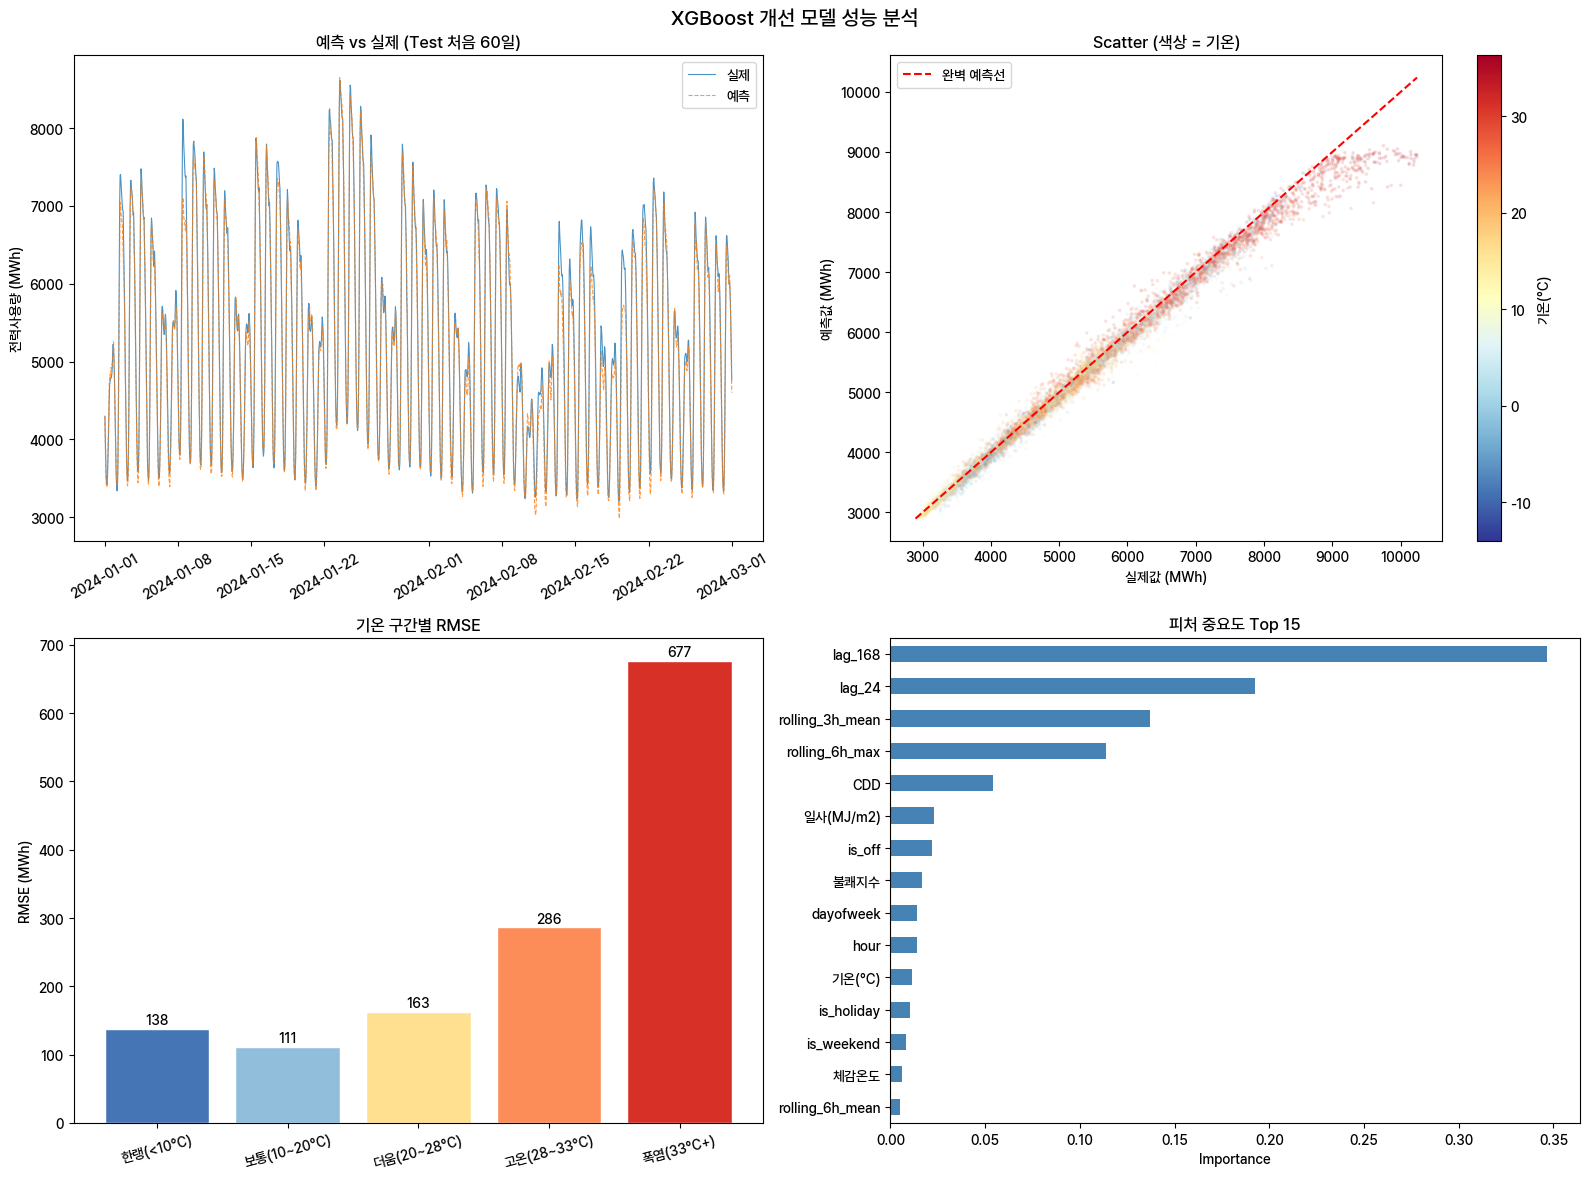

시각화 저장 완료: model_performance.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('XGBoost 개선 모델 성능 분석', fontsize=15, fontweight='bold')

# ── Plot 1: 예측 vs 실제 (전체) ─────────────────────────────────────
ax = axes[0, 0]
sample = test_eval.iloc[:24*60]  # 60일치
ax.plot(sample['datetime'], sample[TARGET], label='실제', alpha=0.8, linewidth=0.8)
ax.plot(sample['datetime'], sample['pred'],  label='예측', alpha=0.8, linewidth=0.8, linestyle='--')
ax.set_title('예측 vs 실제 (Test 처음 60일)')
ax.set_ylabel('전력사용량 (MWh)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# ── Plot 2: Scatter (예측 vs 실제) ──────────────────────────────────
ax = axes[0, 1]
ax.scatter(test_eval[TARGET], test_eval['pred'],
           alpha=0.1, s=3, c=test_eval['기온(°C)'], cmap='RdYlBu_r')
mn = min(test_eval[TARGET].min(), test_eval['pred'].min())
mx = max(test_eval[TARGET].max(), test_eval['pred'].max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='완벽 예측선')
ax.set_xlabel('실제값 (MWh)')
ax.set_ylabel('예측값 (MWh)')
ax.set_title('Scatter (색상 = 기온)')
ax.legend()
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r')
sm.set_array(test_eval['기온(°C)'])
plt.colorbar(sm, ax=ax, label='기온(°C)')

# ── Plot 3: 기온 구간별 RMSE ─────────────────────────────────────────
ax = axes[1, 0]
colors = ['#4575b4','#91bfdb','#fee090','#fc8d59','#d73027']
bars = ax.bar(zone_stats.index, zone_stats['RMSE'], color=colors, edgecolor='white')
ax.set_title('기온 구간별 RMSE')
ax.set_ylabel('RMSE (MWh)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, zone_stats['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10)

# ── Plot 4: 피처 중요도 ──────────────────────────────────────────────
ax = axes[1, 1]
importance = pd.Series(best_model.feature_importances_, index=FEATURES_IMPROVED)
top15 = importance.nlargest(15)
top15.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('피처 중요도 Top 15')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig(r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\4_outputs\08_xgboost_improved_commented\model_performance.png", dpi=300, bbox_inches='tight')
plt.show()
print('시각화 저장 완료: model_performance.png')

## 7. 이전 모델과 성능 비교

## 📈 이전 모델 성능 비교
**개선 단계 요약**
| 단계 | 변경 내용 | 효과 |
|------|---------|------|
| 기존 | 환경+lag 피처 | Test RMSE 244.8, 갭 203.8 |
| 개선 | Rolling + CDD² + 폭염플래그 추가 | RMSE 182.5, 갭 134.0 |

> None으로 표시된 기존 모델 수치는 이전 실험 기록이 없어 비워둔 것

In [10]:
# ── 이전 vs 현재 성능 비교표 ─────────────────────────────────────────
comparison = pd.DataFrame({
    '모델': [
        '기존 (기온+휴일)',
        '기존 (기온+휴일+lag)',
        '기존 (기온+휴일+환경)',
        '기존 (기온+휴일+환경+lag)',
        '개선 (rolling+CDD²+폭염플래그)',
    ],
    'Test RMSE': [None, None, None, 244.8, test_rmse],  # 기존 값 직접 입력
    'Train RMSE': [None, None, None, 41.0, train_rmse],
    '과적합 갭': [None, None, None, 203.8, round(test_rmse - train_rmse, 1)],
    'Test R²': [None, None, None, None, round(test_r2, 4)],
})

print('성능 비교')
print(comparison.to_string(index=False))
print()
print(f'→ 개선 모델 Test RMSE: {test_rmse:.1f}')
print(f'→ 과적합 갭: {test_rmse - train_rmse:.1f} (기존 203.8에서 변화: {(test_rmse-train_rmse) - 203.8:+.1f})')

성능 비교
                     모델  Test RMSE  Train RMSE  과적합 갭  Test R²
             기존 (기온+휴일)        NaN         NaN    NaN      NaN
         기존 (기온+휴일+lag)        NaN         NaN    NaN      NaN
          기존 (기온+휴일+환경)        NaN         NaN    NaN      NaN
      기존 (기온+휴일+환경+lag) 244.800000    41.00000  203.8      NaN
개선 (rolling+CDD²+폭염플래그) 175.482638    52.07019  123.4   0.9864

→ 개선 모델 Test RMSE: 175.5
→ 과적합 갭: 123.4 (기존 203.8에서 변화: -80.4)


## 8. 옵션: 하이브리드 모델 (시간 여유 있을 때)
Linear Regression으로 추세를 먼저 잡고, XGBoost가 잔차를 학습하는 방식입니다.

## 🔬 [옵션] 하이브리드 모델
**아이디어**: Linear Regression이 전체 추세를 잡고, XGBoost가 나머지 오차를 보완

**작동 원리**
```
1단계: Linear → 기온·시간 기반 기본 수요 예측
2단계: 잔차(실제 - Linear예측) 계산
3단계: XGBoost → 잔차만 학습
최종: Linear예측 + XGBoost잔차예측 = 최종예측
```

**결과가 나빴던 이유**: XGBoost 단독(R² 0.9871)이 이미 매우 강력해서 Linear가 추세를 빼는 게 오히려 방해가 됨. 하이브리드는 기본 모델이 약할 때 효과적인 기법.

In [11]:
# ── 하이브리드: Linear + XGBoost 잔차 학습 ──────────────────────────
# 1단계: Linear Regression (추세 학습)
LINEAR_FEATURES = ['기온(°C)', 'CDD', 'HDD', 'hour', 'month', 'is_weekend', 'is_holiday']
LINEAR_FEATURES = [f for f in LINEAR_FEATURES if f in df.columns]

lr = LinearRegression()
lr.fit(X_train[LINEAR_FEATURES], y_train)

lr_train_pred = lr.predict(X_train[LINEAR_FEATURES])
lr_test_pred  = lr.predict(X_test[LINEAR_FEATURES])

# 2단계: 잔차 계산
residual_train = y_train - lr_train_pred
residual_test  = y_test  - lr_test_pred

# 3단계: XGBoost가 잔차 학습
xgb_residual = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
xgb_residual.fit(X_train, residual_train)

# 4단계: 최종 예측 = Linear 예측 + XGBoost 잔차 예측
hybrid_train_pred = lr_train_pred + xgb_residual.predict(X_train)
hybrid_test_pred  = lr_test_pred  + xgb_residual.predict(X_test)

h_train_rmse = np.sqrt(mean_squared_error(y_train, hybrid_train_pred))
h_test_rmse  = np.sqrt(mean_squared_error(y_test,  hybrid_test_pred))
h_test_r2    = r2_score(y_test, hybrid_test_pred)

print('하이브리드 모델 성능')
print(f'Train RMSE : {h_train_rmse:.1f}')
print(f'Test  RMSE : {h_test_rmse:.1f}')
print(f'Test  R²   : {h_test_r2:.4f}')
print(f'과적합 갭  : {h_test_rmse - h_train_rmse:.1f}')
print()
print(f'XGBoost 단독 대비 개선: {test_rmse - h_test_rmse:+.1f} RMSE')

하이브리드 모델 성능
Train RMSE : 61.2
Test  RMSE : 272.6
Test  R²   : 0.9672
과적합 갭  : 211.4

XGBoost 단독 대비 개선: -97.1 RMSE


In [12]:
# ── 최종 결론 출력 ───────────────────────────────────────────────────
print('='*50)
print('최종 모델 성능 요약')
print('='*50)
print(f'[XGBoost 개선]')
print(f'  Train RMSE : {train_rmse:.1f}')
print(f'  Test  RMSE : {test_rmse:.1f}  (기존 244.8)')
print(f'  Test  R²   : {test_r2:.4f}')
print(f'  MAPE       : {test_mape:.2f}%')
print(f'  과적합 갭  : {test_rmse - train_rmse:.1f}  (기존 203.8)')
print()
print(f'[하이브리드]')
print(f'  Train RMSE : {h_train_rmse:.1f}')
print(f'  Test  RMSE : {h_test_rmse:.1f}')
print(f'  Test  R²   : {h_test_r2:.4f}')
print(f'  과적합 갭  : {h_test_rmse - h_train_rmse:.1f}')
print('='*50)

최종 모델 성능 요약
[XGBoost 개선]
  Train RMSE : 52.1
  Test  RMSE : 175.5  (기존 244.8)
  Test  R²   : 0.9864
  MAPE       : 2.00%
  과적합 갭  : 123.4  (기존 203.8)

[하이브리드]
  Train RMSE : 61.2
  Test  RMSE : 272.6
  Test  R²   : 0.9672
  과적합 갭  : 211.4


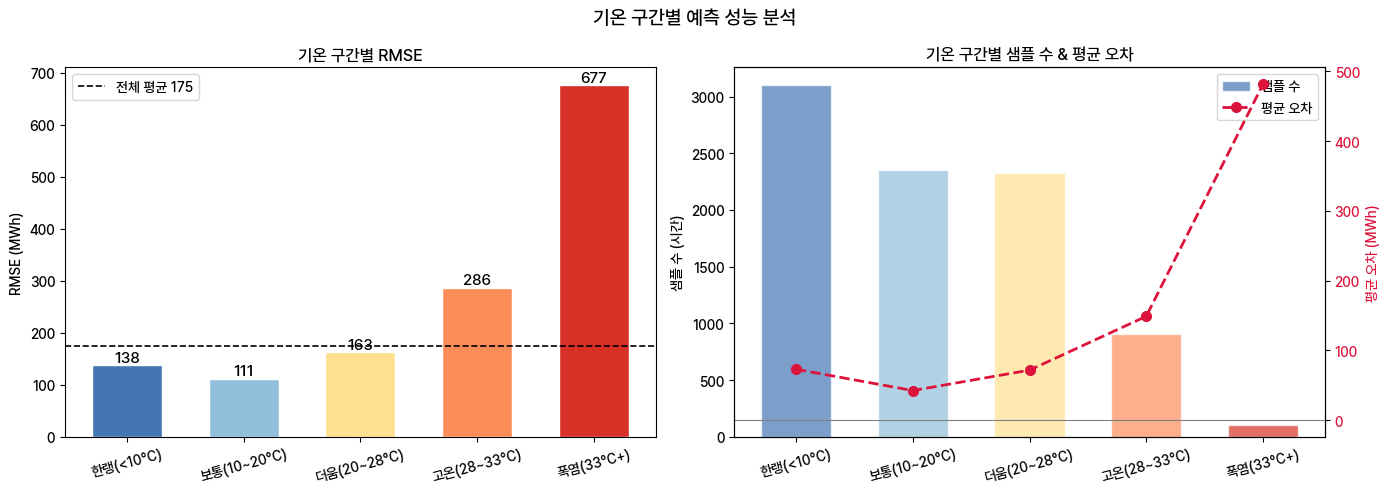

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('기온 구간별 예측 성능 분석', fontsize=14, fontweight='bold')

colors = ['#4575b4', '#91bfdb', '#fee090', '#fc8d59', '#d73027']

# ── Plot 1: 기온 구간별 RMSE 바차트 ─────────────────────────────────
ax = axes[0]
bars = ax.bar(zone_stats.index, zone_stats['RMSE'], color=colors, edgecolor='white', width=0.6)
ax.set_title('기온 구간별 RMSE')
ax.set_ylabel('RMSE (MWh)')
ax.tick_params(axis='x', rotation=15)
ax.axhline(test_rmse, color='black', linestyle='--', linewidth=1.2, label=f'전체 평균 {test_rmse:.0f}')
ax.legend()
for bar, val in zip(bars, zone_stats['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# ── Plot 2: 기온 구간별 샘플 수 + 평균 오차 ─────────────────────────
ax2 = axes[1]
ax2.bar(zone_stats.index, zone_stats['샘플수'], color=colors, edgecolor='white',
        width=0.6, alpha=0.7, label='샘플 수')
ax2.set_ylabel('샘플 수 (시간)')
ax2.set_title('기온 구간별 샘플 수 & 평균 오차')
ax2.tick_params(axis='x', rotation=15)

ax3 = ax2.twinx()
ax3.plot(zone_stats.index, zone_stats['평균오차'], 'o--',
         color='crimson', linewidth=2, markersize=7, label='평균 오차')
ax3.axhline(0, color='gray', linestyle='-', linewidth=0.8)
ax3.set_ylabel('평균 오차 (MWh)', color='crimson')
ax3.tick_params(axis='y', labelcolor='crimson')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\4_outputs\08_xgboost_improved_commented\temp_zone_rmse.png", dpi=300, bbox_inches='tight')
plt.show()

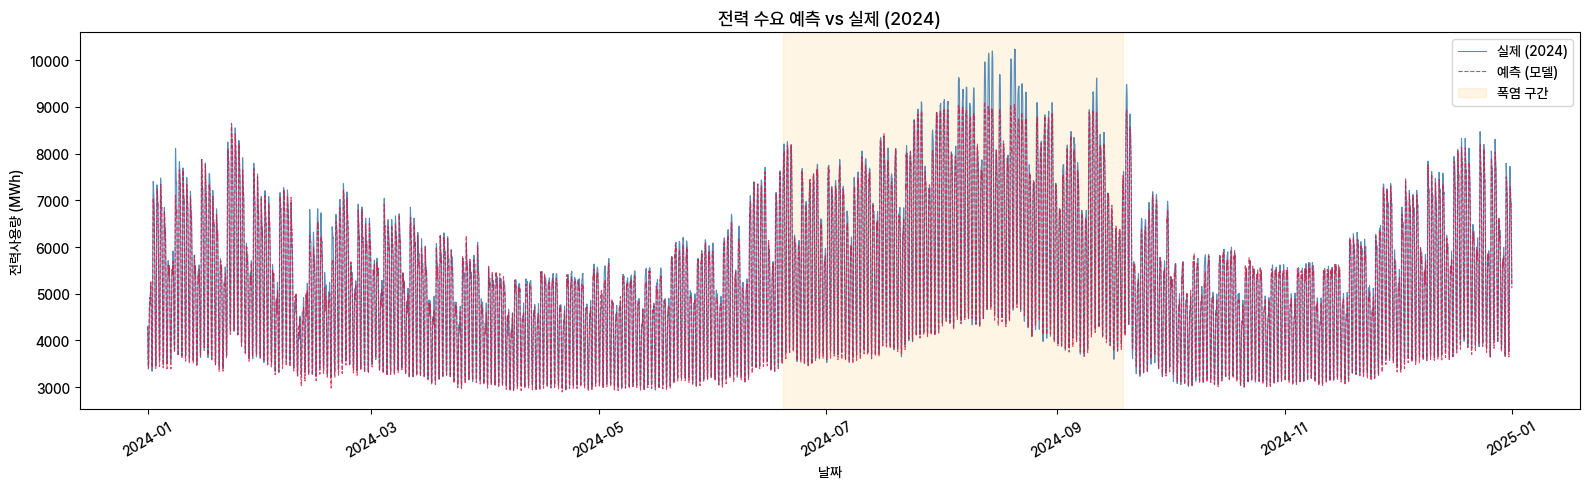

In [15]:
fig, ax = plt.subplots(figsize=(16, 5))

# 실제값
ax.plot(test['datetime'], y_test, 
        label='실제 (2024)', color='steelblue', linewidth=0.8, alpha=0.9)

# 예측값
ax.plot(test['datetime'], test_pred, 
        label='예측 (모델)', color='crimson', linewidth=0.8, alpha=0.8, linestyle='--')

# 폭염 구간 음영
heatwave = test[test['기온(°C)'] >= 33]
if len(heatwave) > 0:
    ax.axvspan(heatwave['datetime'].min(), heatwave['datetime'].max(),
               alpha=0.1, color='orange', label='폭염 구간')

ax.set_title('전력 수요 예측 vs 실제 (2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('전력사용량 (MWh)')
ax.set_xlabel('날짜')
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\4_outputs\08_xgboost_improved_commented\forecast_vs_actual.png", dpi=300, bbox_inches='tight')
plt.show()